<a href="https://colab.research.google.com/github/JatinRaut23/Deep-Learning/blob/main/AlexNet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten,Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
#Normalise pixel values
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

#one-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
model = Sequential()
#layer 1
model.add(Conv2D(96, kernel_size=(3,3), strides=(1,1,), input_shape=(32,32,3),padding = 'same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

#layer 2
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1,), input_shape=(32,32,3),padding = 'same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

#layer 3
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), input_shape=(32,32,3),padding = 'same'))
model.add(Activation('relu'))

#layer 4
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), input_shape=(32,32,3),padding = 'same'))
model.add(Activation('relu'))

#layer 5
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), input_shape=(32,32,3),padding = 'same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

#-------- convolutional pooling with acitvation function done above------

#flatten
model.add(Flatten())

#fully connected layer1
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))      # mean 50% neurons are shutdown

#output layer
model.add(Dense(10))
model.add(Activation('softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [5]:
history = model.fit(X_train,y_train, batch_size=128, epochs=15, validation_split=0.2,
                    verbose=1)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 74ms/step - accuracy: 0.4380 - loss: 1.5952 - val_accuracy: 0.1190 - val_loss: 6.6758
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.6070 - loss: 1.1106 - val_accuracy: 0.4677 - val_loss: 1.7419
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.6892 - loss: 0.8874 - val_accuracy: 0.6623 - val_loss: 1.0095
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.7454 - loss: 0.7338 - val_accuracy: 0.6992 - val_loss: 0.9279
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.7845 - loss: 0.6241 - val_accuracy: 0.7306 - val_loss: 0.7845
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.8199 - loss: 0.5220 - val_accuracy: 0.7340 - val_loss: 0.9015
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8488 - loss: 0.4324 - val_accuracy: 0.7504 - val_loss: 0.8168
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8791 - loss: 0.3473 - 

In [6]:
test_loss, test_acc =model.evaluate(X_test, y_test)
print(test_loss, test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7259 - loss: 1.2327
1.2327028512954712 0.7258999943733215


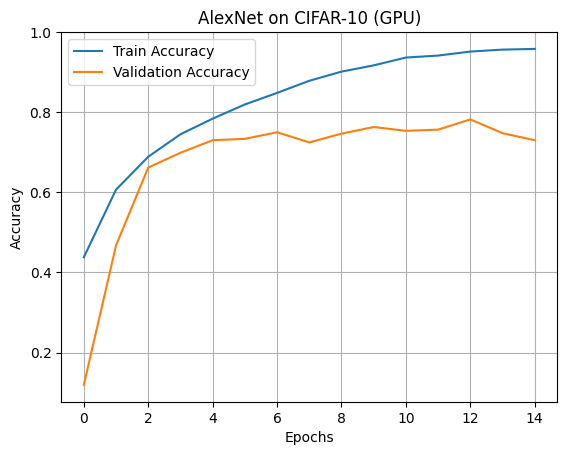

In [8]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('AlexNet on CIFAR-10 (GPU)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()